In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# dados_compras.csv e fraudes_scores.csv

df_compras = pd.read_csv("../1.data/2.processed/dados_compras.csv", parse_dates=["data_compra"])
df_scores = pd.read_csv("../1.data/2.processed/fraudes_scores.csv")

In [3]:
df_compras.head()

,id_compra,produto,categoria_produto,valor_compra,data_compra,dia_semana,hora_compra,pais,pais_agrupado,entrega_doc_1,entrega_doc_2,entrega_doc_3,fraude
0,1,Máquininha Corta Barba Cabelo Peito Perna Pelo...,cat_8d714cd,5.64,2020-03-27 11:51:16,Sexta,11:51,BR,BR,1,0,0,0
1,3,Bicicleta Mountain Fire Bird Rodado 29 Alumini...,cat_e9110c5,339.32,2020-03-25 18:13:38,Quarta,18:13,AR,AR,1,0,0,0
2,7,"Corpinho Avulso Joseph, Josepha Ou Placa Sem Sexo",cat_5d6059e,10.56,2020-03-22 19:20:24,Domingo,19:20,BR,BR,0,0,0,0
3,10,Gamepad Joystick Para Telefono Celular Android...,cat_5d79fb9,30.48,2020-03-11 15:06:38,Quarta,15:06,AR,AR,1,0,1,0
4,11,Escova Dental Curaprox 5460 Ultra Soft Com 3 U...,cat_4744ece,14.85,2020-03-15 19:18:50,Domingo,19:18,BR,BR,1,1,1,0


In [5]:
df_scores.head()

,id_compra,score_1,score_2,score_3,score_4,score_5,score_6,score_7,score_8,score_9,score_10,score_fraude_modelo,fraude
0,1,4,0.7685,94436.24,20.0,0.444828,1.0,5,0.883598,240.0,102.0,66,0
1,3,4,0.7455,242549.09,3.0,0.000000,19.0,23,0.516368,1779.0,77.0,95,0
2,7,4,0.5962,7121.78,2.0,0.398000,0.0,11,0.204991,127.0,125.0,71,0
3,10,4,0.4759,40143.12,50.0,0.000000,41.0,3,0.735790,4701.0,940.0,60,0
4,11,4,0.8353,121926.06,39.0,0.186957,34.0,24,0.943792,3248.0,132.0,10,0


In [6]:
df_compras.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   id_compra          150000 non-null  int64         
 1   produto            150000 non-null  str           
 2   categoria_produto  150000 non-null  str           
 3   valor_compra       150000 non-null  float64       
 4   data_compra        150000 non-null  datetime64[us]
 5   dia_semana         150000 non-null  str           
 6   hora_compra        150000 non-null  str           
 7   pais               150000 non-null  str           
 8   pais_agrupado      150000 non-null  str           
 9   entrega_doc_1      150000 non-null  int64         
 10  entrega_doc_2      150000 non-null  int64         
 11  entrega_doc_3      150000 non-null  int64         
 12  fraude             150000 non-null  int64         
dtypes: datetime64[us](1), float64(1), int64(5), str(6)
memo

## Verificar:

- o numero de fraudes;
- valores médios, valores máximos de fraudes;
- quais países tem os maiores valores de fraude;

para buscar colunas

nome_dataset['nome_coluna'] -> busca uma coluna

como buscar linhas?

`loc` e `iloc`


In [9]:
df_compras.iloc[:6, 2:6]

,categoria_produto,valor_compra,data_compra,dia_semana
0,cat_8d714cd,5.64,2020-03-27 11:51:16,Sexta
1,cat_e9110c5,339.32,2020-03-25 18:13:38,Quarta
2,cat_5d6059e,10.56,2020-03-22 19:20:24,Domingo
3,cat_5d79fb9,30.48,2020-03-11 15:06:38,Quarta
4,cat_4744ece,14.85,2020-03-15 19:18:50,Domingo
5,cat_d3aa8de,1138.64,2020-03-16 11:49:05,Segunda


In [11]:
df_compras.loc[:6, ["id_compra", "valor_compra", "dia_semana"]]

,id_compra,valor_compra,dia_semana
0,1,5.64,Sexta
1,3,339.32,Quarta
2,7,10.56,Domingo
3,10,30.48,Quarta
4,11,14.85,Domingo
5,13,1138.64,Segunda
6,15,9.19,Sexta


In [12]:
df_compras[df_compras['fraude'] == 1]

,id_compra,produto,categoria_produto,valor_compra,data_compra,dia_semana,hora_compra,pais,pais_agrupado,entrega_doc_1,entrega_doc_2,entrega_doc_3,fraude
7,17,Chaveiro Lindo Do Thor,cat_d9753d4,5.46,2020-03-28 17:09:53,Sábado,17:09,BR,BR,0,0,0,1
20,46,Teclado Macbook Pro A1278 Us,cat_df60aa8,25.68,2020-03-19 12:27:13,Quinta,12:27,BR,BR,1,1,1,1
29,70,Bota Masculina Coturno Venetto Couro Legítimo ...,cat_9bacaa5,20.46,2020-03-20 10:04:31,Sexta,10:04,BR,BR,1,0,1,1
37,82,"Álcool Gel 70% Antisséptico -1 Gl 5 Lt.=140,00...",cat_d0759b1,36.93,2020-03-27 21:08:55,Sexta,21:08,BR,BR,1,0,0,1
41,88,Pneu Cooper Classic Tour 185/65 R14 86t,cat_feb8e6e,174.30,2020-03-22 12:38:55,Domingo,12:38,BR,BR,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
149920,68163,3640 Diamantes Free Fire Solo Id ( Carga Ya )...,cat_13e9101,61.39,2020-04-19 23:25:08,Domingo,23:25,AR,AR,0,0,0,1
149934,80594,Chips Ddd Livre Da Vivo,cat_390d0f1,67.36,2020-04-08 16:59:37,Quarta,16:59,BR,BR,0,0,0,1
149937,19218,Álcool Em Gel Asseptgel 70% Original Start 1k...,cat_0f47e2a,24.67,2020-04-10 14:21:26,Sexta,14:21,BR,BR,1,1,0,1
149991,84682,Notebook Positivo Premium Xs7005 Intel® I3 1t...,cat_e5ca240,380.91,2020-04-15 11:17:27,Quarta,11:17,BR,BR,1,0,1,1


`and` - & , `or` - | `not` - ~

In [13]:
df_compras[(df_compras['fraude'] == 1) & (df_compras['valor_compra'] > 500)]

,id_compra,produto,categoria_produto,valor_compra,data_compra,dia_semana,hora_compra,pais,pais_agrupado,entrega_doc_1,entrega_doc_2,entrega_doc_3,fraude
698,1342,Samsung S10+ Plus 128gb Tela 6.4 Anatel Lacrad...,cat_43b9c10,822.99,2020-03-10 21:11:25,Terça,21:11,BR,BR,0,0,0,1
1165,2244,Apple iPhone X 256 Gb Prata 3 Gb Ram,cat_43b9c10,947.04,2020-03-18 20:47:42,Quarta,20:47,BR,BR,1,0,0,1
5248,10023,Apple Watch Series 5 40mm Nota Fiscal +pelicul...,cat_228843f,590.77,2020-03-17 20:59:59,Terça,20:59,BR,BR,1,0,0,1
7116,13679,iPhone 8 Plus 64gb,cat_43b9c10,597.04,2020-03-29 18:56:37,Domingo,18:56,ES,Outros,1,0,1,1
7531,14449,Apple iPhone 8 Plus 64gb Original Vitrine Desb...,cat_43b9c10,590.77,2020-03-17 20:23:38,Terça,20:23,BR,BR,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
145015,131777,Cochecito Cybex Priam Capota Xxl Reversible Mo...,cat_4aecf2c,1407.15,2020-04-01 17:58:27,Quarta,17:58,AR,AR,1,0,1,1
145523,126468,Notebook Gamer Acer An515-54-56sa I5 16gb Gtx ...,cat_e5ca240,1023.85,2020-04-17 23:22:46,Sexta,23:22,BR,BR,1,0,0,1
146813,90329,Smart Tv Oled Lg 55 55b8s 4k Uhd Ips Hdr Webos...,cat_23212a0,1841.60,2020-04-16 06:05:47,Quinta,06:05,US,Outros,1,0,0,1
149833,52286,Smarttv Samsung 4k 2019 Ru7100 75 Un75ru7100gxzd,cat_23212a0,1431.37,2020-04-07 12:00:35,Terça,12:00,BR,BR,1,0,0,1


In [16]:
df_compras[(df_compras['fraude'] == 1) & (df_compras['valor_compra'] > 500) & (df_compras['hora_compra'] < '06:00')]

,id_compra,produto,categoria_produto,valor_compra,data_compra,dia_semana,hora_compra,pais,pais_agrupado,entrega_doc_1,entrega_doc_2,entrega_doc_3,fraude
23589,45733,Apple Watch Series 3 38mm Gps - Lacrado,cat_228843f,660.52,2020-03-27 01:45:35,Sexta,01:45,BR,BR,1,0,0,1
25582,49598,Samsung Galaxy S10+ S10 + G975 128gb 8gb Ram 4...,cat_43b9c10,778.71,2020-03-10 04:16:20,Terça,04:16,BR,BR,1,0,1,1
43069,83661,Caixa De Som Jbl Boombox Black Original 1 Ano ...,cat_bba902e,898.20,2020-03-19 02:21:15,Quinta,02:21,BR,BR,0,0,0,1
44260,85925,Placa De Vídeo Galax Rtx 2060 Super Ex White 8...,cat_fb277dd,557.04,2020-03-28 05:17:17,Sábado,05:17,BR,BR,1,0,0,1
55661,108414,Placa De Vídeo Galax Rtx 2070 Super Ex 8gb Gdd...,cat_fb277dd,736.15,2020-03-28 05:38:53,Sábado,05:38,BR,BR,1,0,0,1
57186,111373,iPhone 11 Lacrado 64gb Garantia Apple + Brindes,cat_43b9c10,1057.86,2020-03-09 02:03:42,Segunda,02:03,BR,BR,0,0,0,1
64284,125233,Placa De Vídeo Galax Rtx 2060 Super Ex White 8...,cat_fb277dd,531.25,2020-03-31 00:20:07,Terça,00:20,BR,BR,0,0,0,1
64916,126537,Celular Xiaomi Redmi Note 8 4 Gb Ram 64 Gb Mem...,cat_43b9c10,503.67,2020-03-14 02:28:19,Sábado,02:28,BR,BR,0,0,0,1
71909,140142,Xiaomi Mi 9t Pro 128gb 6gb Ram 48mp Global+cap...,cat_43b9c10,556.00,2020-03-10 00:11:36,Terça,00:11,BR,BR,0,0,0,1
74150,144540,Notebook Gamer Acer An515-51-75kz I7 16gb 1050...,cat_e5ca240,1154.08,2020-03-28 04:59:56,Sábado,04:59,BR,BR,1,0,0,1


In [22]:
fraudes_madrugada_500 = df_compras.loc[(df_compras['fraude'] == 1) & (df_compras['valor_compra'] > 500) & (df_compras['hora_compra'] < '06:00'), ["id_compra", "produto", "valor_compra", "hora_compra"]]
fraudes_madrugada_500

,id_compra,produto,valor_compra,hora_compra
23589,45733,Apple Watch Series 3 38mm Gps - Lacrado,660.52,01:45
25582,49598,Samsung Galaxy S10+ S10 + G975 128gb 8gb Ram 4...,778.71,04:16
43069,83661,Caixa De Som Jbl Boombox Black Original 1 Ano ...,898.20,02:21
44260,85925,Placa De Vídeo Galax Rtx 2060 Super Ex White 8...,557.04,05:17
55661,108414,Placa De Vídeo Galax Rtx 2070 Super Ex 8gb Gdd...,736.15,05:38
57186,111373,iPhone 11 Lacrado 64gb Garantia Apple + Brindes,1057.86,02:03
64284,125233,Placa De Vídeo Galax Rtx 2060 Super Ex White 8...,531.25,00:20
64916,126537,Celular Xiaomi Redmi Note 8 4 Gb Ram 64 Gb Mem...,503.67,02:28
71909,140142,Xiaomi Mi 9t Pro 128gb 6gb Ram 48mp Global+cap...,556.00,00:11
74150,144540,Notebook Gamer Acer An515-51-75kz I7 16gb 1050...,1154.08,04:59


In [26]:
fraudes_madrugada_500.sort_values(by='valor_compra', ascending=False)

,id_compra,produto,valor_compra,hora_compra
121797,12641,Drone Dji Phantom 4 Pro V2,2706.46,03:39
82767,56306,Macbook Air 13 128gb I5 1.6ghz 8gb 2019 Mvfh2 ...,1557.80,00:14
74150,144540,Notebook Gamer Acer An515-51-75kz I7 16gb 1050...,1154.08,04:59
57186,111373,iPhone 11 Lacrado 64gb Garantia Apple + Brindes,1057.86,02:03
43069,83661,Caixa De Som Jbl Boombox Black Original 1 Ano ...,898.20,02:21
25582,49598,Samsung Galaxy S10+ S10 + G975 128gb 8gb Ram 4...,778.71,04:16
124789,111312,Rode Nt2a Microfono Condenser Multipatron De E...,775.55,05:57
80608,58225,Forno Photo Dome Invel,759.72,05:48
95141,59881,Dji Spark Combo - Branco,759.59,03:39
55661,108414,Placa De Vídeo Galax Rtx 2070 Super Ex 8gb Gdd...,736.15,05:38


### Variáveis categóricas e variáveis numéricas
variável categórica trás informações de categorias. Ex: 'dia_semana', 'pais', 'produto'
- geralmente vão em gráficos de barra: porque podemos analisar contagens...

variáveis numéricas elas trazem informações de valores. Ex: 'valor_compra', 'score_1', 'score_fraude_modelo'
- médias, medianas, valores mínimos e máximos. 


| Tipo | Gráficos | Por quê |
|---|---|---|
| Numérica | histograma, boxplot, violin plot | mostram a **distribuição**: onde os valores se concentram, o quanto se espalham e onde estão os extremos |
| Categórica | barras | mostram a **contagem** de cada grupo |


In [27]:
df_compras.columns

Index(['id_compra', 'produto', 'categoria_produto', 'valor_compra',
       'data_compra', 'dia_semana', 'hora_compra', 'pais', 'pais_agrupado',
       'entrega_doc_1', 'entrega_doc_2', 'entrega_doc_3', 'fraude'],
      dtype='str')

In [28]:
df_scores.columns

Index(['id_compra', 'score_1', 'score_2', 'score_3', 'score_4', 'score_5',
       'score_6', 'score_7', 'score_8', 'score_9', 'score_10',
       'score_fraude_modelo', 'fraude'],
      dtype='str')

In [29]:
df_compras.describe()

,id_compra,valor_compra,data_compra,entrega_doc_1,entrega_doc_2,entrega_doc_3,fraude
count,150000.000000,150000.000000,150000,150000.000000,150000.000000,150000.000000,150000.000000
mean,75000.500000,43.523134,2020-03-30 23:41:40.546253,0.902353,0.160607,0.554193,0.050000
min,1.000000,0.020000,2020-03-08 00:02:15,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,9.380000,2020-03-18 12:40:32.250000,1.000000,0.000000,0.000000,0.000000
50%,75000.500000,20.610000,2020-03-31 00:08:33,1.000000,0.000000,1.000000,0.000000
75%,112500.250000,40.692500,2020-04-12 12:40:16,1.000000,0.000000,1.000000,0.000000
max,150000.000000,3696.350000,2020-04-21 23:59:56,1.000000,1.000000,1.000000,1.000000
std,43301.414527,91.557888,NaN,0.296837,0.367169,0.497056,0.217946


- `count` = diz quantos itens tem dentro da nossa coluna (só os itens que não são nulos)
- `mean` = média (soma tudo e divide pelo valor de x [x é o nosso número de itens])
- `min` e `max` = valores minimos e máximos da coluna
- `std` = desvio padrão (o quanto os valores se espalham em torno da média; quanto maior, mais diferentes as compras são entre si)
- `25%`, `50%` e o `75%` - quartis 
- `50%` equivale a `mediana` = que é o valor do meio

In [30]:
df_scores.describe()

,id_compra,score_1,score_2,score_3,score_4,score_5,score_6,score_7,score_8,score_9,score_10,score_fraude_modelo,fraude
count,150000.000000,150000.000000,150000.000000,1.500000e+05,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,75000.500000,3.705407,0.730486,2.416847e+05,21.658987,0.220641,51.166187,14.193513,0.497532,2305.382387,299.709287,48.066240,0.050000
std,43301.414527,0.753206,0.127292,8.112654e+05,20.041292,2.434995,709.446986,14.161216,0.288348,1712.319718,320.728227,28.995122,0.217946
min,1.000000,1.000000,0.000000,1.600000e-01,0.000000,0.000000,-5.000000,0.000000,0.000004,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,4.000000,0.690200,1.157216e+04,2.000000,0.000000,1.000000,3.000000,0.246819,910.000000,42.000000,23.000000,0.000000
50%,75000.500000,4.000000,0.755500,4.371165e+04,14.000000,0.104875,8.000000,9.000000,0.495990,1937.000000,193.000000,48.000000,0.000000
75%,112500.250000,4.000000,0.801100,1.287591e+05,50.000000,0.282938,33.000000,21.000000,0.746508,3444.000000,458.000000,73.000000,0.000000
max,150000.000000,4.000000,1.000000,1.387874e+07,50.000000,833.333333,145274.000000,58.000000,0.999995,7544.000000,2225.000000,100.000000,1.000000


## Histograma - númerica

conta uma história - distribuição dos valores.

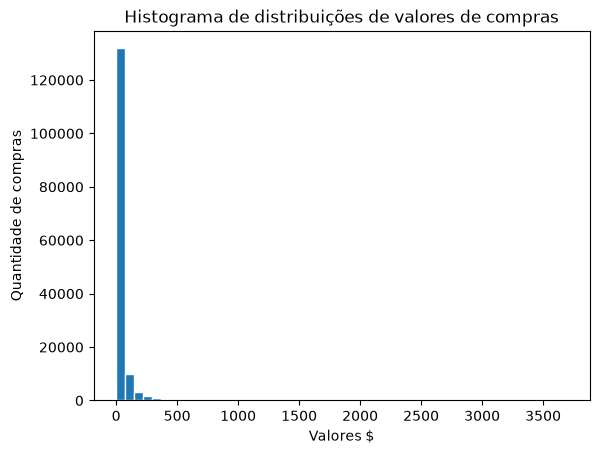

In [36]:
plt.hist(df_compras['valor_compra'], bins=50, edgecolor='white') #bins default são 10
plt.title("Histograma de distribuições de valores de compras")
plt.xlabel("Valores $")
plt.ylabel("Quantidade de compras")
plt.show()


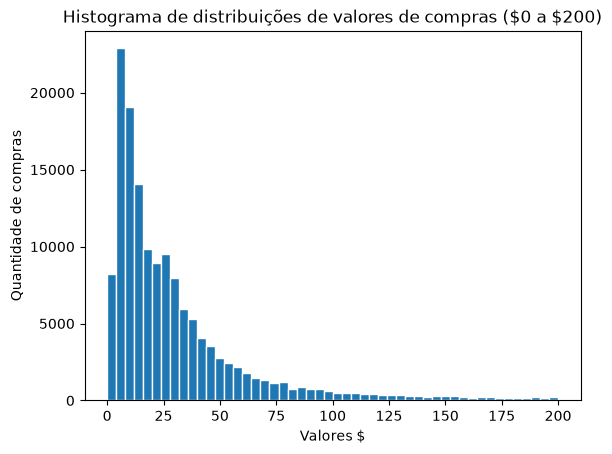

In [45]:
plt.hist(df_compras['valor_compra'], range=(0, 200), bins=50, edgecolor='white') #bins default são 10
plt.title("Histograma de distribuições de valores de compras (\\$0 a \\$200)")
plt.xlabel("Valores \\$")
plt.ylabel("Quantidade de compras")
plt.show()


| Valor | `np.log10` | Por quê |
|---|---|---|
| R$ 1 | 0 | 10⁰ = 1 |
| R$ 10 | 1 | 10¹ = 10 |
| R$ 100 | 2 | 10² = 100 |
| R$ 1.000 | 3 | 10³ = 1000 |


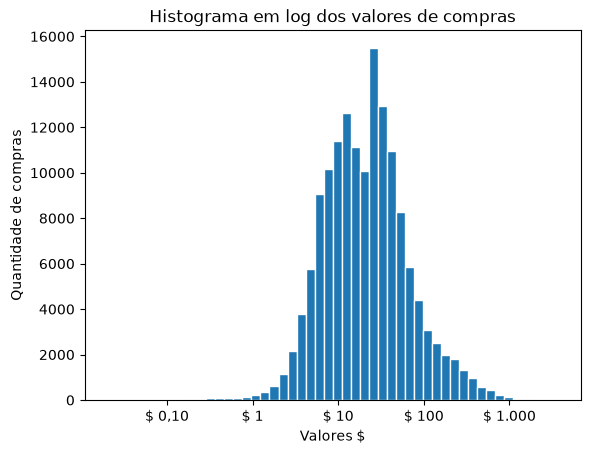

In [48]:
# como podemos colocar os valores maiores em exposição sem perder o estilo do gráfico?
# log é sempre fazer a pergunta "10 elevado a quanto dá esse número?"
# log de base 10 = np.log10

log_valor_compras = np.log10(df_compras['valor_compra'])
marcas = [-1, 0, 1, 2, 3]
nomes = ["$ 0,10", "$ 1", "$ 10", "$ 100", "$ 1.000"]

plt.hist(log_valor_compras, bins=50, edgecolor='white') #bins default são 10
plt.xticks(marcas, nomes)
plt.title("Histograma em log dos valores de compras")
plt.xlabel("Valores \\$")
plt.ylabel("Quantidade de compras")
plt.show()

# -1, 0, 1, 2, 3

### boxplot
 é gráfico de caixa, que nos permite entender a nossa distruibuição de valores - entender se existem outliers, entender a concentração dos valores.

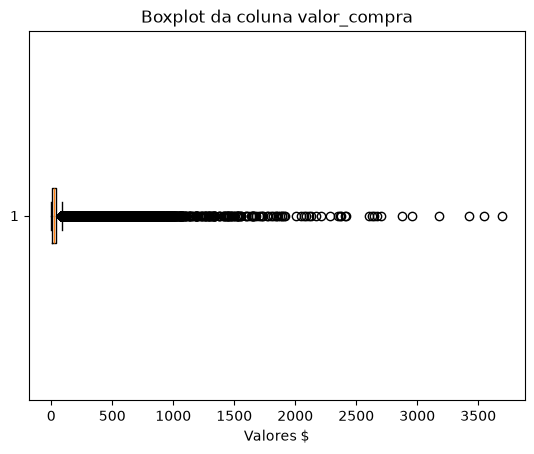

In [53]:
plt.boxplot(df_compras['valor_compra'], orientation="horizontal")
plt.title("Boxplot da coluna valor_compra")
plt.xlabel("Valores \\$")
plt.show()

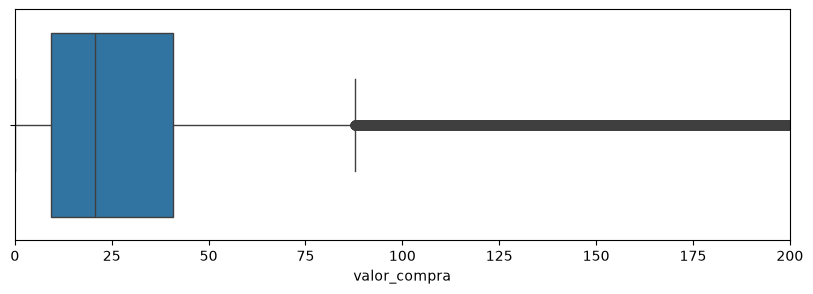

In [56]:
fig, ax = plt.subplots(figsize=(10, 3))
sns.boxplot(x=df_compras['valor_compra'], ax=ax)
ax.set_xlim(0, 200)   # mesmo limite que você usou no range do histograma
plt.show()

| Parte do boxplot | De onde vem |
|---|---|
| Linha dentro da caixa | a **mediana** (percentil 50) |
| Começo da caixa | o **percentil 25** |
| Fim da caixa | o **percentil 75** |
| A caixa inteira | os **50% de compras do meio** |
| Bigode da esquerda |o menor valor que não é extremo |
| Bigode da direita | o maior valor que não é extremo |
| Ponto isolado | um **valor extremo** (*outlier*) |

## gráficos para variáveis categóricas

In [65]:
df_compras['fraude'].value_counts(normalize=True)

fraude
0    0.95
1    0.05
Name: proportion, dtype: float64

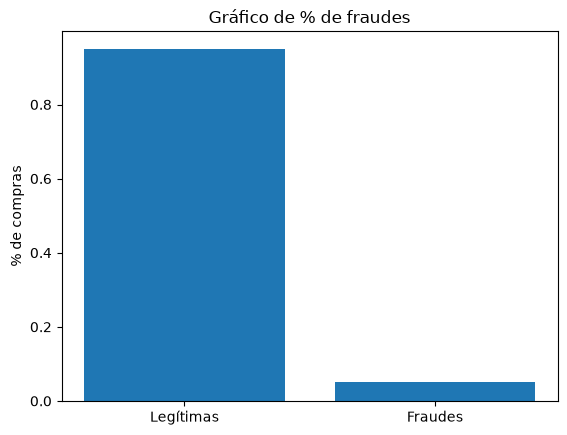

In [72]:
valores_fraudes_percent = df_compras['fraude'].value_counts(normalize=True).sort_index()
plt.bar(["Legítimas", "Fraudes"], valores_fraudes_percent.values)
plt.title("Gráfico de % de fraudes")
plt.ylabel("% de compras")
plt.show()

In [73]:
df_compras.columns

Index(['id_compra', 'produto', 'categoria_produto', 'valor_compra',
       'data_compra', 'dia_semana', 'hora_compra', 'pais', 'pais_agrupado',
       'entrega_doc_1', 'entrega_doc_2', 'entrega_doc_3', 'fraude'],
      dtype='str')

In [74]:
df_compras['pais_agrupado'].value_counts().sort_index()

pais_agrupado
AR         31964
BR        111628
Outros      6408
Name: count, dtype: int64

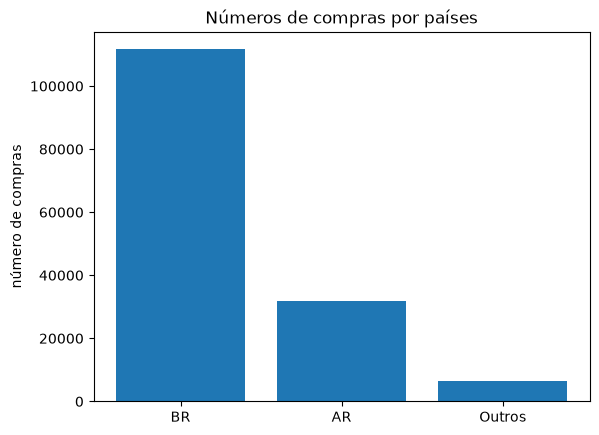

In [76]:
paises_contagem = df_compras['pais_agrupado'].value_counts()
plt.bar(paises_contagem.index, paises_contagem.values)
plt.title("Números de compras por países")
plt.ylabel("número de compras")
plt.show()